#### Предложите новый метод инициализации центроидов кластеров для алгоритма K-средних. Перечислите преимущества и недостатки методов Forgy, Random Partition и вашей собственной инициализации.
Идея предложенного мною метода инициализации центроидов кластеров - вычислять дисперсию по каждому признаку в выборке,  потом отобрать признак с наибольшей дисперсии и отобрать несколько центроидов, равномерно отдалённых друг от друга по этому признаку, например, если кластеров задано всего 2, то первый центроид по отобранному признаку будет соотвествовать квантилю 80, а второй - квантилю 20, это также позволит бороться с выбросами по данному признаку; если кластеров 3 - то квантили 80, 20, 50 и тд.\
Forgy\
Суть метода Forgy - случайный выбор K точек из данных в качестве начальных центроидов\
Этот метод простейший и самый быстрый\
Минусы - наименее надёжный и полностью случайный\
Random Partition \
Суть метода - Random Partition случайным образом присваивает каждому объекту метку какого-либо кластера, а затем вычисляет центроиды как среднее этих случайных групп\
Преимущества - Простота и скорость, получил широкое применение\
Недостатки - низкая надёжность и чувствительность к выбросам\
Предложенный мной метод\
Преимущества - детерменированность, простота, скорость \
Недостатки - центроиды равномерно распределены только по одной оси


#### Опишите, как можно использовать кластеризацию для ускорения работы модели KNN. Подсказка: что такое kd-дерево?
Сужение пространтсва поиска, вместо того, чтобы проверять все точки, алгоритм сначала определяет, в какой области находится рассматриваемый объект и ищет данные только в этой области. kd-дерево - это структура данных, которая рекурсивно разбивает пространство (выполняет иерархическую кластеризацию). Оно делит пространство по гиперплоскостям, перпендикулярным осям координат, создавая древовидную структуру. В процессе поиска алгоритм спускается по дереву, отсекая целые подпространства, которые гарантированно не могут содержать ближайших соседей. Это позволяет найти ответ проверив лишь малую часть точек.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import kmeans_plusplus, KMeans, DBSCAN, AgglomerativeClustering
from scipy.spatial.distance import cdist, pdist
from collections import deque
from scipy.stats import multivariate_normal
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.neighbors import BallTree
from scipy.cluster.hierarchy import linkage, fcluster
import random
from sklearn.mixture import GaussianMixture

In [2]:
df = pd.read_json('data/train.json')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [3]:
new_feat = ['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']
for word in new_feat:
    df[word] = df["features"].apply(lambda x: 1 if x is not None and word in x else 0)

new_feat.append("bathrooms")
new_feat.append("bedrooms")
new_feat.append("price")
new_feat.append("created")
new_feat.append("latitude")
new_feat.append("longitude")
new_feat.append("interest_level")

q1 = df['price'].quantile(0.01)
q99 = df['price'].quantile(0.99)

df = df[new_feat]
df = df[(df['price'] > q1) & (df['price'] < q99)]

q1 = df['longitude'].quantile(0.01)
q99 = df['longitude'].quantile(0.99)
df = df[(df['longitude'] > q1) & (df['longitude'] < q99)]

q1 = df['latitude'].quantile(0.01)
q99 = df['latitude'].quantile(0.99)
df = df[(df['latitude'] > q1) & (df['latitude'] < q99)]

df['created'] = pd.to_datetime(df['created'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46400 entries, 4 to 124009
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Elevator           46400 non-null  int64         
 1   HardwoodFloors     46400 non-null  int64         
 2   CatsAllowed        46400 non-null  int64         
 3   DogsAllowed        46400 non-null  int64         
 4   Doorman            46400 non-null  int64         
 5   Dishwasher         46400 non-null  int64         
 6   NoFee              46400 non-null  int64         
 7   LaundryinBuilding  46400 non-null  int64         
 8   FitnessCenter      46400 non-null  int64         
 9   Pre-War            46400 non-null  int64         
 10  LaundryinUnit      46400 non-null  int64         
 11  RoofDeck           46400 non-null  int64         
 12  OutdoorSpace       46400 non-null  int64         
 13  DiningRoom         46400 non-null  int64         
 14  HighSpeedI

In [4]:
df = df.sort_values('created')
df['year'] = df['created'].dt.year
df['month'] = df['created'].dt.month
df['day'] = df['created'].dt.day
df = df.drop(['created'], axis=1)
train_size = int(df.shape[0] * 0.7)
X = df.drop(['price'], axis=1)
y = df['price']
X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

In [5]:
onehot = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = onehot.fit_transform(X_train[['interest_level']])
encoded_train = pd.DataFrame(encoded_array, columns=onehot.get_feature_names_out(), index=X_train.index)
X_train = X_train.drop(['interest_level'], axis=1)
X_train = pd.concat([X_train, encoded_train], axis=1)

encoded_test = pd.DataFrame(onehot.transform(X_test[['interest_level']]), columns=onehot.get_feature_names_out(), index=X_test.index)
X_test = X_test.drop(['interest_level'], axis=1)
X_test = pd.concat([X_test, encoded_test], axis=1)

In [6]:
class myKMeans:
    def __init__(self, n_clusters, max_iter=50, tol=0.0001, init='kmeans++', distance='euclidean', num_init='auto'):
        self.__n_clusters = n_clusters
        self.__max_iter = max_iter
        self.__tol = tol
        self.__init = init
        self.__distance = distance
        self.__num_init = num_init
        self.__clusters_centers = None
        self.__labels = None
        self.__inertia = None

    def __calculate_distance(self, x, y):
        if self.__distance == 'euclidean':
            return np.sqrt(np.sum((x - y)**2))
        if self.__distance == 'manhattan':
            return np.sum(np.abs(x - y))
        if self.__distance == 'chebyshev':
            return np.max(np.abs(x - y))

    def __initialization_centers(self, X):
        if self.__init == 'random':
            self.__clusters_centers = X[np.random.choice(len(X), size=self.__n_clusters, replace=False)]
        elif self.__init == 'kmeans++':
            self.__clusters_centers, indices = kmeans_plusplus(X, n_clusters=self.__n_clusters, random_state=0)
        elif self.__init == 'maximin':
            rng = np.random.default_rng(0)
            n_samples = X.shape[0]
            self.__clusters_centers = [X[rng.integers(0, n_samples)]]
            for i in range(1, self.__n_clusters):
                distances = np.array([
                    min([self.__calculate_distance(point, center) for center in self.__clusters_centers])
                    for point in X
                ])
                next_center_idx = np.argmax(distances)
                self.__clusters_centers.append(X[next_center_idx])
            self.__clusters_centers = np.array(self.__clusters_centers)
        elif self.__init == 'random_partition':
            rng = np.random.default_rng(0)
            n_samples = X.shape[0]
            labels = rng.integers(0, self.__n_clusters, size=n_samples)
            self.__clusters_centers = np.array([X[labels == i].mean(axis=0) for i in range(self.__n_clusters)])

    def __find_best_initialization(self, X):
        if self.__init == 'random' or self.__init == 'random_partition':
            if self.__num_init == 'auto':
                self.__num_init = 10
            best_centers = None
            max_min_dist = 0
            for i in range(self.__num_init):
                self.__clusters_centers = None
                self.__initialization_centers(X)
                distances = np.array([
                    [self.__calculate_distance(center_i, center_j) for center_j in self.__clusters_centers]
                    for center_i in self.__clusters_centers
                ])
                distances[np.where(distances == 0)] = np.inf
                min_dist = np.min(distances)
                if min_dist > max_min_dist:
                    max_min_dist = min_dist
                    best_centers = self.__clusters_centers
            self.__clusters_centers = best_centers
        else:
            self.__initialization_centers(X)

    def _compute_distances(self, X):

        diff = X[:, np.newaxis, :] - self.__clusters_centers[np.newaxis, :, :]
        
        if self.__distance == 'euclidean':
            return np.sqrt(np.sum(diff ** 2, axis=2))
        elif self.__distance == 'manhattan':
            return np.sum(np.abs(diff), axis=2)
        elif self.__distance == 'chebyshev':
            return np.max(np.abs(diff), axis=2)

    def _run_kmeans(self, X):
        for iteration in range(self.__max_iter):
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)

            new_centers = np.array([
                X[labels == i].mean(axis=0) if np.any(labels == i) else self.__clusters_centers[i]
                for i in range(self.__n_clusters)
            ])
            
            shift = np.max(np.abs(new_centers - self.__clusters_centers))
            self.__clusters_centers = new_centers
            
            if shift < self.__tol:
                break
        
        distances = self._compute_distances(X)
        min_dist_sq = np.min(distances ** 2, axis=1)
        inertia = np.sum(min_dist_sq)
        
        return labels, self.__clusters_centers.copy(), inertia

    def fit_predict(self, X):
        self.__find_best_initialization(X)

        labels, centers, inertia = self._run_kmeans(X)
        self.__labels = labels
        self.__clusters_centers = centers
        self.__inertia = inertia
        
        return self.__labels

    def predict(self, X):
        if(self.__clusters_centers is None):
            return None
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

    def compute_inertia(self, X, labels):
        X_array = X if isinstance(X, np.ndarray) else X.values
        inertia = 0
        for i, center in enumerate(self.__clusters_centers):
            mask = labels == i
            if np.any(mask):
                diff = X_array[mask] - center
                inertia += np.sum(diff ** 2)
        return float(inertia)

    @property
    def clusters_centers(self):
        return self.__clusters_centers

    @property
    def inertia(self):
        return self.__inertia

    @property
    def labels(self):
        return self.__labels
    

In [7]:
model = myKMeans(n_clusters=30)
labels = model.fit_predict(X_train[['latitude', 'longitude']].values)
labels_test = model.predict(X_test[['latitude', 'longitude']].values)

<Axes: xlabel='latitude', ylabel='longitude'>

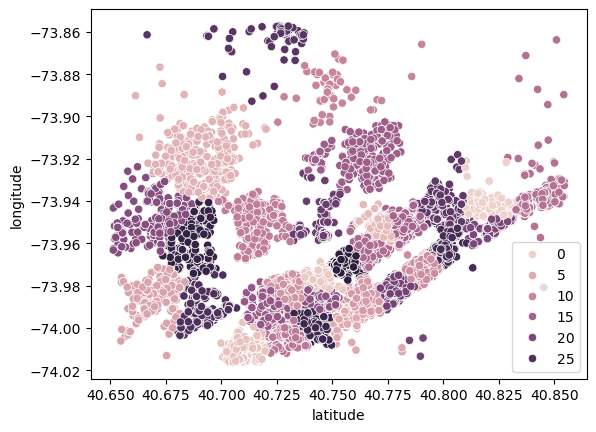

In [8]:
sns.scatterplot(x=X_train["latitude"], y=X_train["longitude"], hue=labels)

<Axes: xlabel='latitude', ylabel='longitude'>

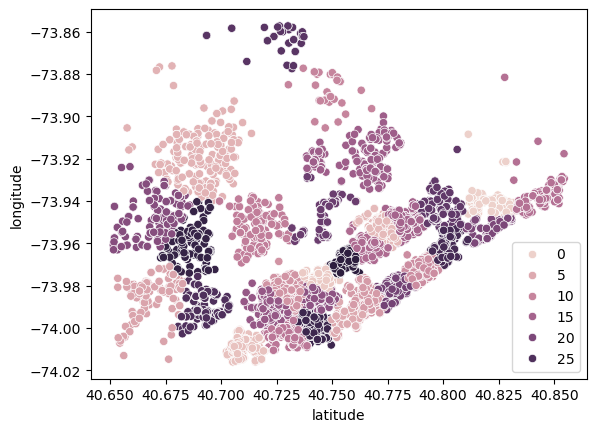

In [9]:
sns.scatterplot(x=X_test['latitude'], y=X_test['longitude'], hue=labels_test)

In [10]:
res_df = pd.DataFrame(columns=['silhouette_score_train', 'inertia_train', 'silhouette_score_test', 'inertia_test'])

In [11]:
my_km_sil_tr = silhouette_score(X_train[['latitude', 'longitude']], labels, metric='euclidean')
inert_tr = model.compute_inertia(X_train[['latitude', 'longitude']], labels)
my_km_sil_test = silhouette_score(X_test[['latitude', 'longitude']], labels_test, metric='euclidean')
inert_test = model.compute_inertia(X_test[['latitude', 'longitude']], labels_test)
res_df.loc['MyKMeans'] = [my_km_sil_tr, inert_tr, my_km_sil_test, inert_test]
res_df

,silhouette_score_train,inertia_train,silhouette_score_test,inertia_test
MyKMeans,0.444379,1.228621,0.444893,0.560955


In [12]:
km = KMeans(n_clusters=30)
km_labels = km.fit_predict(X_train[['latitude', 'longitude']])
km_labels_test = km.predict(X_test[['latitude', 'longitude']])

<Axes: xlabel='latitude', ylabel='longitude'>

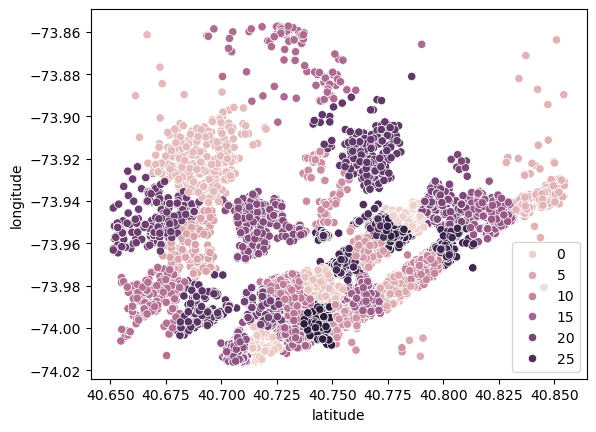

In [13]:
sns.scatterplot(x=X_train["latitude"], y=X_train["longitude"], hue=km_labels)

<Axes: xlabel='latitude', ylabel='longitude'>

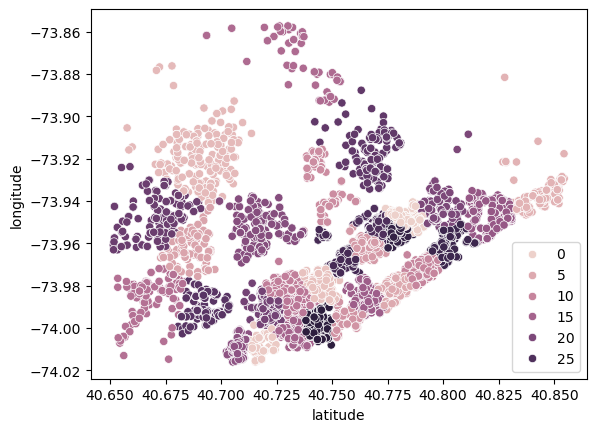

In [14]:
sns.scatterplot(x=X_test["latitude"], y=X_test["longitude"], hue=km_labels_test)

In [15]:
def comp_inertia(X, labels, centers):
    X_array = X if isinstance(X, np.ndarray) else X.values
    inertia = 0
    for i, center in enumerate(centers):
        mask = labels == i
        if any(mask):
            diff = X_array[mask] - center
            inertia += np.sum(diff**2)
    return float(inertia)

In [16]:
km_sil_tr = silhouette_score(X_train[['latitude', 'longitude']], km_labels, metric='euclidean')
km_inert_tr = comp_inertia(X_train[['latitude', 'longitude']], km_labels, km.cluster_centers_)
km_sil_test = silhouette_score(X_test[['latitude', 'longitude']], km_labels_test, metric='euclidean')
km_inert_test = comp_inertia(X_test[['latitude', 'longitude']], km_labels_test, km.cluster_centers_)
res_df.loc['StdKMeans'] = [km_sil_tr, km_inert_tr, km_sil_test, km_inert_test]
res_df

,silhouette_score_train,inertia_train,silhouette_score_test,inertia_test
MyKMeans,0.444379,1.228621,0.444893,0.560955
StdKMeans,0.423538,1.289187,0.422711,0.578175


In [17]:
def labels_to_new_features(labels, X_train, labels_test, X_test):
    minmax = MinMaxScaler()
    new_feat_train = pd.DataFrame(minmax.fit_transform(labels.reshape(-1, 1)), columns=['label'], index=X_train.index)
    new_feat_test = pd.DataFrame(minmax.transform(labels_test.reshape(-1, 1)), columns=['label'], index=X_test.index)
    X_train_new = pd.concat([X_train, new_feat_train], axis=1)
    X_test_new = pd.concat([X_test, new_feat_test], axis=1)

    return X_train_new, X_test_new

In [18]:
X_train_my_km, X_test_my_km = labels_to_new_features(labels, X_train, labels_test, X_test)

In [43]:
def work(X_train, y_train, X_test, y_test, res, method_name):
    lasso_cv = LassoCV(alphas=None, cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_train, y_train)
    print(f"Лучший alpha: {lasso_cv.alpha_:.4f}")
    lasso = Lasso(alpha=lasso_cv.alpha_)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    y_pred_train = lasso.predict(X_train)

    coeffs = pd.Series(lasso.coef_, index=X_train.columns)
    print(f"Коэффицинт label: {coeffs['label']}")
    coeffs_sorted = coeffs.reindex(coeffs.abs().sort_values(ascending=False).index)
    print(coeffs_sorted)

    r2_test = r2_score(y_test, y_pred)
    mae_test = mean_absolute_error(y_test, y_pred)
    rmse_test = (mean_squared_error(y_test, y_pred))**0.5

    r2_train = r2_score(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = (mean_squared_error(y_train, y_pred_train))**0.5

    res.loc[method_name] = [mae_test, mae_train, rmse_test, rmse_train, r2_test, r2_train]

In [44]:
res_lasso = pd.DataFrame(columns=['mae_test', 'mae_train', 'rmse_test', 'rmse_train', 'r2_test', 'r2_train'])
work(X_train_my_km, y_train, X_test_my_km, y_test, res_lasso, 'MyKMeans')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: 297.2207369276732
longitude               -13949.443276
bathrooms                 1565.086931
interest_level_low         698.854315
bedrooms                   510.450977
Doorman                    397.768498
label                      297.220737
interest_level_medium      178.753771
Elevator                   108.153940
Terrace                     81.944935
Pre-War                    -74.579263
Dishwasher                  65.906048
month                       25.019854
day                          2.849420
DogsAllowed                  0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
NewConstruction              0.000000
SwimmingPool                 0.

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.64343,0.650601


In [45]:
X_train_km, X_test_km = labels_to_new_features(km_labels, X_train, km_labels_test, X_test)
work(X_train_km, y_train, X_test_km, y_test, res_lasso, 'StdKMeans')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: 101.06890573141294
longitude               -13473.159903
bathrooms                 1568.349747
interest_level_low         703.536832
bedrooms                   508.907664
Doorman                    379.656079
interest_level_medium      181.275130
Elevator                   112.583125
label                      101.068906
Terrace                     80.411966
Pre-War                    -66.382586
Dishwasher                  66.078799
month                       25.657312
day                          2.908076
DogsAllowed                  0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
NewConstruction              0.000000
SwimmingPool                 0

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402


In [22]:
class myDBScan:
    def __init__(self, eps=0.05, min_samples=5, metric='euclidean'):
        self.__eps = eps
        self.__min_samples = min_samples
        self.__metric = metric
        self.__tree = None
        self.__labels = None
        self.__core_sample_indices = None      
            
    def fit_predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
        elif hasattr(X, 'to_numpy'):
            X = X.to_numpy()
        
        X = np.asarray(X, dtype=np.float32)
        n_samples = X.shape[0]
        self.__core_sample_indices = list()
        self.__tree = BallTree(X, metric=self.__metric)
        labels = np.full(n_samples, -2, dtype=np.int16)
        unwatched = set(range(n_samples))
        cur_label = -1
        processed = 0
        
        while unwatched:
            sample_idx = next(iter(unwatched))
            unwatched.remove(sample_idx)
            neighbors = self.__tree.query_radius([X[sample_idx]], r=self.__eps, 
                                                  return_distance=False)[0]
            eps_okr = neighbors[neighbors != sample_idx]
            
            if len(eps_okr) < self.__min_samples:
                labels[sample_idx] = -1
            else:
                self.__core_sample_indices.append(sample_idx)
                cur_label += 1
                labels[sample_idx] = cur_label
                check = deque(eps_okr.tolist())
                
                while check:
                    check_idx = check.popleft()
                    
                    if labels[check_idx] == -1:
                        labels[check_idx] = cur_label
                        unwatched.discard(check_idx)
                        continue
                    
                    if labels[check_idx] != -2:
                        continue
                    neighbors_check = self.__tree.query_radius([X[check_idx]], r=self.__eps,
                                                                return_distance=False)[0]
                    eps_okr_check = neighbors_check[neighbors_check != check_idx]
                    
                    if len(eps_okr_check) >= self.__min_samples:
                        self.__core_sample_indices.append(check_idx)
                    
                    labels[check_idx] = cur_label
                    unwatched.discard(check_idx)
                    processed += 1
                    if processed % 1000 == 0:
                        print(f"Processed: {processed}/{n_samples}, Clusters: {cur_label + 1}")
                    check.extend(eps_okr_check.tolist())
            
            processed += 1
            if processed % 1000 == 0:
                print(f"Processed: {processed}/{n_samples}, Clusters: {cur_label + 1}")
        self.__labels = np.array(labels)
        self.__core_sample_indices = np.array(self.__core_sample_indices)
        return self.__labels

    @property
    def labels(self):
        return self.__labels

    @property
    def core_sample_indices(self):
        return self.__core_sample_indices


In [23]:
mydb = myDBScan(eps=0.004, min_samples=50)
all_labels_my_db = mydb.fit_predict(X[['latitude', 'longitude']].values)

Processed: 1000/46400, Clusters: 1
Processed: 2000/46400, Clusters: 1
Processed: 3000/46400, Clusters: 1
Processed: 4000/46400, Clusters: 1
Processed: 5000/46400, Clusters: 1
Processed: 6000/46400, Clusters: 1
Processed: 7000/46400, Clusters: 1
Processed: 8000/46400, Clusters: 1
Processed: 9000/46400, Clusters: 1
Processed: 10000/46400, Clusters: 1
Processed: 11000/46400, Clusters: 1
Processed: 12000/46400, Clusters: 1
Processed: 13000/46400, Clusters: 1
Processed: 14000/46400, Clusters: 1
Processed: 15000/46400, Clusters: 1
Processed: 16000/46400, Clusters: 1
Processed: 17000/46400, Clusters: 1
Processed: 18000/46400, Clusters: 1
Processed: 19000/46400, Clusters: 1
Processed: 20000/46400, Clusters: 1
Processed: 21000/46400, Clusters: 1
Processed: 22000/46400, Clusters: 1
Processed: 23000/46400, Clusters: 1
Processed: 24000/46400, Clusters: 1
Processed: 25000/46400, Clusters: 1
Processed: 26000/46400, Clusters: 1
Processed: 27000/46400, Clusters: 1
Processed: 28000/46400, Clusters: 1
P

<Axes: xlabel='latitude', ylabel='longitude'>

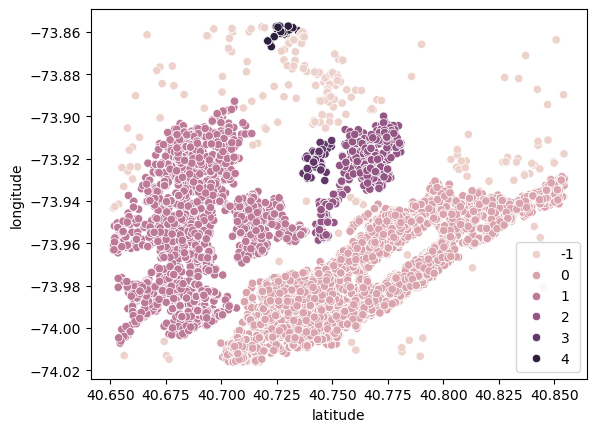

In [24]:
sns.scatterplot(x=X['latitude'], y=X['longitude'], hue=all_labels_my_db)

In [25]:
dbscan = DBSCAN(eps=0.008, min_samples=100, n_jobs=-1, algorithm='ball_tree')
all_labels_db = dbscan.fit_predict(X[['latitude', 'longitude']].values)

<Axes: xlabel='latitude', ylabel='longitude'>

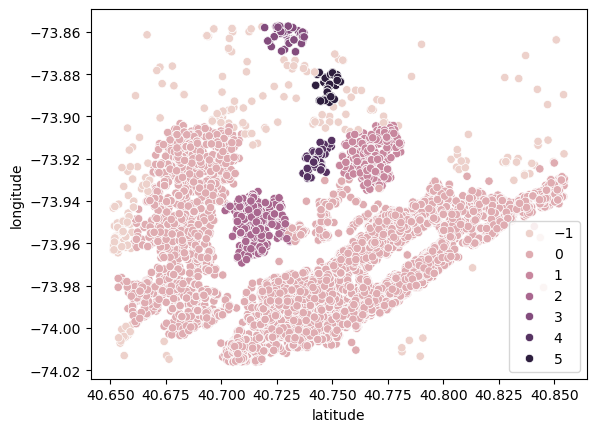

In [26]:
sns.scatterplot(x=X['latitude'], y=X['longitude'], hue=all_labels_db)

In [27]:
my_db_sil = silhouette_score(X[['latitude', 'longitude']], all_labels_my_db, metric='euclidean')
db_sil = silhouette_score(X[['latitude', 'longitude']], all_labels_db, metric='euclidean')
res_df.loc['MyDBSCAN'] = [my_db_sil, np.nan, np.nan, np.nan]
res_df.loc['StdDBSCAN'] = [db_sil, np.nan, np.nan, np.nan]
res_df

,silhouette_score_train,inertia_train,silhouette_score_test,inertia_test
MyKMeans,0.444379,1.228621,0.444893,0.560955
StdKMeans,0.423538,1.289187,0.422711,0.578175
MyDBSCAN,0.133422,NaN,NaN,NaN
StdDBSCAN,0.021189,NaN,NaN,NaN


In [28]:
class myAglomerativeClustering:
    def __init__(self, n_clusters, metric='euclidean', linkage='ward'):
        self.__n_clusters = n_clusters
        self.__metric = metric
        self.__linkage = linkage
        self.__labels = None

    def __compute_distances(self, X):
        if self.__metric == 'euclidean':
            return cdist(X, X, metric='euclidean').astype(np.float32)
        elif self.__metric == 'manhattan':
            return cdist(X, X, metric='cityblock').astype(np.float32)
        elif self.__metric == 'chebyshev':
            return cdist(X, X, metric='chebyshev').astype(np.float32)

    def __compute_linkage_distance(self, d_uv, d_us, d_vs, size_u, size_v, size_s):
        if self.__linkage == 'single':
            return min(d_us, d_vs)
        if self.__linkage == 'complete':
            return max(d_us, d_vs)
        if self.__linkage == 'average':
            return (size_u * d_us + size_v * d_vs) / (size_v + size_u)
        if self.__linkage == 'ward':
            total = size_u + size_v + size_s
            alpha_u = (size_u + size_s) / total
            alpha_v = (size_v + size_s) / total
            beta = -size_s / total
            return alpha_u * d_us + alpha_v * d_vs + beta*d_uv
            

    def fit_predict(self, X):
        distances = self.__compute_distances(X)
        np.fill_diagonal(distances, np.inf)
        n_samples = X.shape[0]
        labels = np.arange(n_samples)
        clusters_size = np.ones(n_samples, dtype=int)
        active_clusters = list(range(n_samples))
        
        for iteration in range(n_samples - self.__n_clusters):
            flat_min_idx = np.argmin(distances)
            i, j = np.unravel_index(flat_min_idx, distances.shape)
            if i > j:
                i, j = j, i
            labels[labels == j] = i
            size_i = clusters_size[i]
            size_j = clusters_size[j]
            new_size = size_i + size_j
            clusters_size[i] = new_size
            active_clusters.remove(j)
            
            for k in active_clusters:
                if k == i:
                    distances[i, i] = np.inf
                    continue
                new_dist = self.__compute_linkage_distance(distances[i, j], distances[i, k], distances[j, k], size_i, size_j, clusters_size[k])
                distances[i, k] = new_dist
                distances[k, i] = new_dist
                
            distances[:, j] = np.inf
            distances[j, :] = np.inf
            if iteration % 1000 == 0:
                print(f"{iteration} / {n_samples - self.__n_clusters}")
        unique_labels = np.unique(labels)
        label_map = {old : new for new, old in enumerate(unique_labels)}
        self.__labels = np.array([label_map[label] for label in labels])
        return self.__labels

    def fit_predict_fast(self, X):
        n_samples = X.shape[0]

        dist_vector = self.__compute_distances(X)
        Z = linkage(dist_vector, method=self.__linkage, metric=self.__metric)
        self.__labels = fcluster(Z, self.__n_clusters, criterion='maxclust') - 1
        return self.__labels

    @property
    def labels(self):
        return self.__labels
    

In [29]:
X_agl = X_train[['latitude', 'longitude']].values[:10000]
myagl = myAglomerativeClustering(n_clusters=30)
all_labels_my_agl = myagl.fit_predict(X_agl)

0 / 9970
1000 / 9970
2000 / 9970
3000 / 9970
4000 / 9970
5000 / 9970
6000 / 9970
7000 / 9970
8000 / 9970
9000 / 9970


<Axes: xlabel='latitude', ylabel='longitude'>

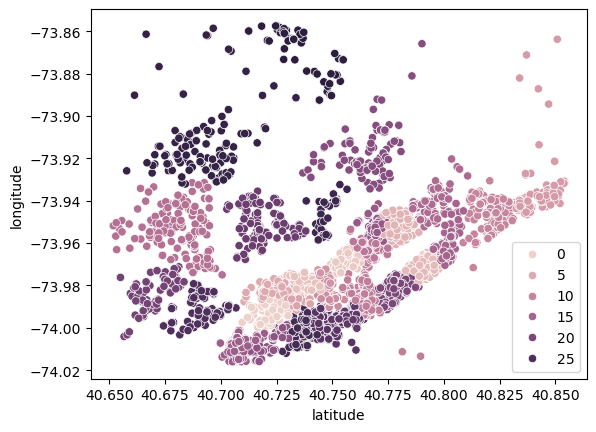

In [30]:
sns.scatterplot(x=X_train['latitude'][:10000], y=X_train['longitude'][:10000], hue=all_labels_my_agl)

In [31]:
std_agl_model = AgglomerativeClustering(n_clusters=30, linkage='ward', metric='euclidean')
all_labels_agl_std = std_agl_model.fit_predict(X_agl)

<Axes: xlabel='latitude', ylabel='longitude'>

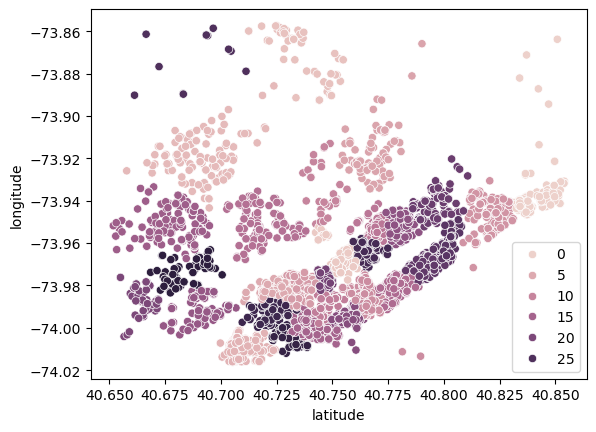

In [32]:
sns.scatterplot(x=X_train['latitude'][:10000], y=X_train['longitude'][:10000], hue=all_labels_agl_std)

In [33]:
my_agl_sil = silhouette_score(X[['latitude', 'longitude']][:10000], all_labels_my_agl, metric='euclidean')
agl_sil = silhouette_score(X[['latitude', 'longitude']][:10000], all_labels_agl_std, metric='euclidean')
res_df.loc['MyAgglomerative'] = [my_agl_sil, np.nan, np.nan, np.nan]
res_df.loc['StdAgglomerative'] = [agl_sil, np.nan, np.nan, np.nan]
res_df

,silhouette_score_train,inertia_train,silhouette_score_test,inertia_test
MyKMeans,0.444379,1.228621,0.444893,0.560955
StdKMeans,0.423538,1.289187,0.422711,0.578175
MyDBSCAN,0.133422,NaN,NaN,NaN
StdDBSCAN,0.021189,NaN,NaN,NaN
MyAgglomerative,0.412054,NaN,NaN,NaN
StdAgglomerative,0.418328,NaN,NaN,NaN


In [34]:
class myGMM:
    def __init__(self, n_components, tol=1e-3, max_iter=100, random_state=67, covarience_type='full'):
        self.__n_components = n_components
        self.__tol = tol
        self.__max_iter = max_iter
        self.__random_state = random_state
        self.__covarience_type = covarience_type
        self.__weights = None
        self.__means = None
        self.__covariences = None

    def __compute_log_likelihood(self, X):
        n_samples = X.shape[0]
        likelihood = np.zeros((n_samples, self.__n_components))
        
        for k in range(self.__n_components):
            likelihood[:, k] = multivariate_normal.pdf(
                X,
                mean=self.__means[k],
                cov=self.__covariences[k]
            )
        
        weighted_likelihood = likelihood * self.__weights
        return np.sum(np.log(weighted_likelihood.sum(axis=1)))

    def __initialization(self, X):
        random.seed(self.__random_state)
        np.random.seed(self.__random_state)
        n_samples, n_features = X.shape
        self.__weights = np.full(self.__n_components, 1 / self.__n_components)
        random_indices = np.random.choice(n_samples, size=self.__n_components, replace=False)
        self.__means = X[random_indices]

        cov_data = np.cov(X, rowvar=False)
        
        if self.__covarience_type == 'spherical':
            self.__covariences = np.array([np.mean(np.diag(cov_data))] * self.__n_components)
        elif self.__covarience_type == 'diag':
            diag_cov = np.diag(cov_data) + 1e-6
            self.__covariences = np.array([diag_cov.copy() for _ in range(self.__n_components)])
        elif self.__covarience_type == 'tied':
            self.__covariences = cov_data + 1e-6 * np.eye(n_features)
        elif self.__covarience_type == 'full':
            self.__covariences = np.array([cov_data + 1e-6 * np.eye(n_features) for _ in range(self.__n_components)])

    def __E_step(self, X):
        n_samples = X.shape[0]
        likelihood = np.zeros((n_samples, self.__n_components))
        for k in range(self.__n_components):
            likelihood[:, k] = multivariate_normal.pdf(
                X, 
                mean=self.__means[k], 
                cov=self.__covariences[k]
            )

        weighted_likelihood = likelihood * self.__weights
        responsibilities = weighted_likelihood / weighted_likelihood.sum(axis=1, keepdims=True)

        return responsibilities

    def __M_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        N_k = responsibilities.sum(axis=0)
        
        self.__weights = N_k / n_samples
        self.__means = (responsibilities.T @ X) / N_k[:, np.newaxis]

        reg_cov = 1e-6

        if self.__covarience_type == 'spherical':
            self.__covariences = np.zeros(self.__n_components)
            for k in range(self.__n_components):
                if N_k[k] > 0:
                    diff = X - self.__means[k]
                    squared_dist = np.sum(diff ** 2, axis=1)
                    self.__covariences[k] = np.sum(responsibilities[:, k] * squared_dist) / (N_k[k] * n_features)
            self.__covariences = np.maximum(self.__covariences, reg_cov)

        elif self.__covarience_type == 'diag':
            self.__covariences = np.zeros((self.__n_components, n_features))
            for k in range(self.__n_components):
                if N_k[k] > 0:
                    diff = X - self.__means[k]
                    weighted_diff = (responsibilities[:, k:k+1] * diff)
                    self.__covariences[k] = np.sum(weighted_diff * diff, axis=0) / N_k[k]
            self.__covariences = np.maximum(self.__covariences, reg_cov)

        elif self.__covarience_type == 'tied':
            cov_sum = np.zeros((n_features, n_features))
            for k in range(self.__n_components):
                if N_k[k] > 0:
                    diff = X - self.__means[k]
                    weighted_diff = (responsibilities[:, k:k+1] * diff)
                    cov_sum += weighted_diff.T @ diff
            self.__covariences = cov_sum / n_samples
            self.__covariences += reg_cov * np.eye(n_features)

        elif self.__covarience_type == 'full':
            self.__covariences = np.zeros((self.__n_components, n_features, n_features))
            for k in range(self.__n_components):
                if N_k[k] > 0:
                    diff = X - self.__means[k]
                    weighted_diff = (responsibilities[:, k:k+1] * diff)
                    self.__covariences[k] = weighted_diff.T @ diff / N_k[k]
            self.__covariences += reg_cov * np.eye(n_features)[None, :, :]
        
        
    def fit(self, X):
        self.__initialization(X)

        prev_log_likelihood = -np.inf

        for i in range(self.__max_iter):
            resp = self.__E_step(X)
            self.__M_step(X, resp)
            
            current_log_likelihood = self.__compute_log_likelihood(X)
            
            if abs(current_log_likelihood - prev_log_likelihood) < self.__tol:
                break
            
            prev_log_likelihood = current_log_likelihood

    def predict(self, X):
        responsibilities = self.__E_step(X)
        return np.argmax(responsibilities, axis=1)
    
    def predict_proba(self, X):
        return self.__E_step(X)

    @property
    def weights(self):
        return self.__weights

    @property
    def means(self):
        return self.__means

    @property
    def covariences(self):
        return self.__covariences

In [35]:
my_gmm = myGMM(n_components=30)
my_gmm.fit(X_train[['latitude', 'longitude']].values)
my_labels_train = my_gmm.predict(X_train[['latitude', 'longitude']].values)
my_labels_test = my_gmm.predict(X_test[['latitude', 'longitude']].values)

<Axes: xlabel='latitude', ylabel='longitude'>

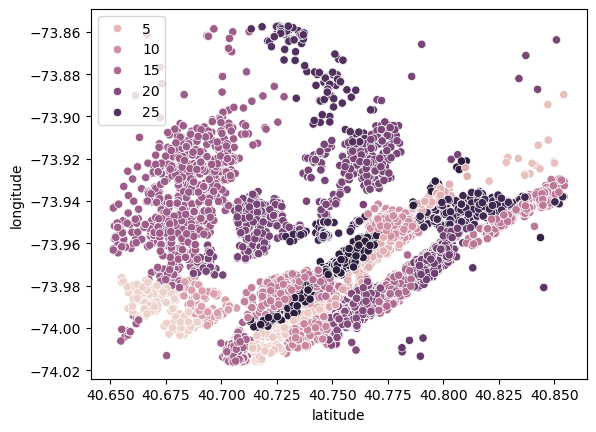

In [36]:
sns.scatterplot(x=X_train['latitude'], y=X_train['longitude'], hue=my_labels_train)

<Axes: xlabel='latitude', ylabel='longitude'>

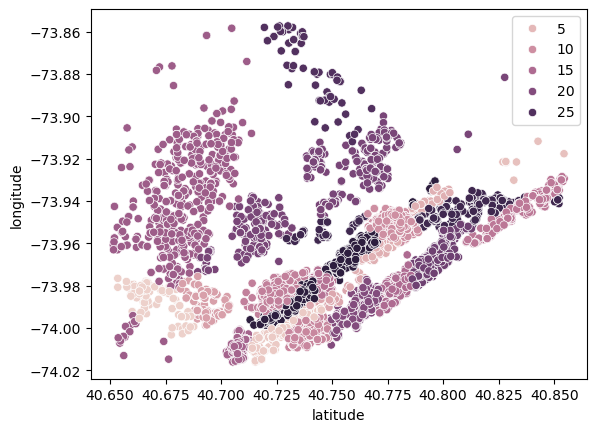

In [37]:
sns.scatterplot(x=X_test['latitude'], y=X_test['longitude'], hue=my_labels_test)

In [38]:
gmm = GaussianMixture(
    n_components=30,
    covariance_type='full',
    max_iter=100,
    tol=1e-3,
    random_state=67
)
gmm.fit(X_train[['latitude', 'longitude']])
std_gmm_labels_train = gmm.predict(X_train[['latitude', 'longitude']])
std_gmm_labels_test = gmm.predict(X_test[['latitude', 'longitude']])

<Axes: xlabel='latitude', ylabel='longitude'>

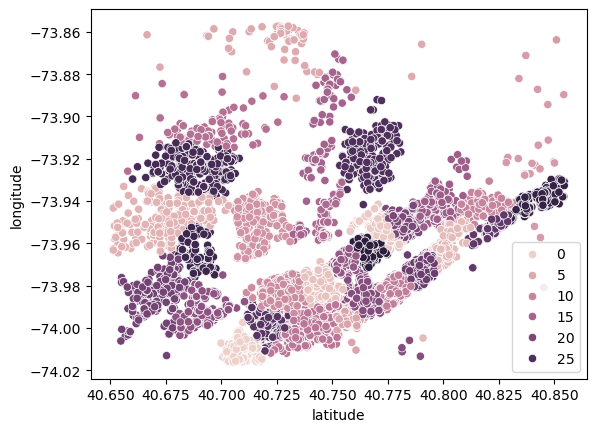

In [39]:
sns.scatterplot(x=X_train['latitude'], y=X_train['longitude'], hue=std_gmm_labels_train)

<Axes: xlabel='latitude', ylabel='longitude'>

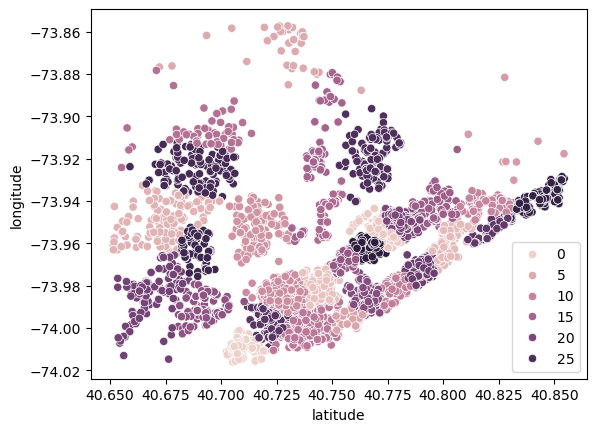

In [40]:
sns.scatterplot(x=X_test['latitude'], y=X_test['longitude'], hue=std_gmm_labels_test)

In [41]:
my_gmm_sil_train = silhouette_score(X_train[['latitude', 'longitude']], my_labels_train, metric='euclidean')
my_gmm_sil_test = silhouette_score(X_test[['latitude', 'longitude']], my_labels_test, metric='euclidean')
std_gmm_sil_train = silhouette_score(X_train[['latitude', 'longitude']], std_gmm_labels_train, metric='euclidean')
std_gmm_sil_test = silhouette_score(X_test[['latitude', 'longitude']], std_gmm_labels_test, metric='euclidean')
res_df.loc['MyGMM'] = [my_agl_sil, np.nan, my_gmm_sil_test, np.nan]
res_df.loc['StdGMM'] = [agl_sil, np.nan, std_gmm_sil_test, np.nan]
res_df

,silhouette_score_train,inertia_train,silhouette_score_test,inertia_test
MyKMeans,0.444379,1.228621,0.444893,0.560955
StdKMeans,0.423538,1.289187,0.422711,0.578175
MyDBSCAN,0.133422,NaN,NaN,NaN
StdDBSCAN,0.021189,NaN,NaN,NaN
MyAgglomerative,0.412054,NaN,NaN,NaN
StdAgglomerative,0.418328,NaN,NaN,NaN
MyGMM,0.412054,NaN,0.251784,NaN
StdGMM,0.418328,NaN,0.431911,NaN


In [55]:
X_train_my_gmm, X_test_my_gmm = labels_to_new_features(my_labels_train, X_train, my_labels_test, X_test)
work(X_train_my_gmm, y_train, X_test_my_gmm, y_test, res_lasso, 'MyGMM')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: -109.91332779304354
longitude               -13262.319740
bathrooms                 1567.628979
interest_level_low         707.193499
bedrooms                   507.656306
Doorman                    381.748432
interest_level_medium      182.861223
Elevator                   112.890968
label                     -109.913328
Terrace                     78.065759
Dishwasher                  66.933134
Pre-War                    -65.756613
month                       25.498143
day                          2.970911
DogsAllowed                  0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
NewConstruction              0.000000
SwimmingPool                 

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789
StdAgglomerative,625.471671,633.717211,918.894954,968.248469,0.628346,0.621161


In [57]:
X_train_std_gmm, X_test_std_gmm = labels_to_new_features(std_gmm_labels_train, X_train, std_gmm_labels_test, X_test)
work(X_train_std_gmm, y_train, X_test_std_gmm, y_test, res_lasso, 'StdGMM')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: 123.86541219490154
longitude               -13964.153412
bathrooms                 1567.692686
interest_level_low         703.040846
bedrooms                   508.096634
Doorman                    378.254134
interest_level_medium      181.103539
label                      123.865412
Elevator                   112.358520
Terrace                     79.937289
Dishwasher                  66.481995
Pre-War                    -65.960034
month                       24.976116
day                          2.981412
DogsAllowed                  0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
NewConstruction              0.000000
SwimmingPool                 0

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789
StdAgglomerative,625.471671,633.717211,918.894954,968.248469,0.628346,0.621161
StdGMM,643.352385,628.538724,949.090245,941.239996,0.640858,0.647910


In [49]:
my_db_labels_train = all_labels_my_db[:train_size]
my_db_labels_test = all_labels_my_db[train_size:]

X_train_my_db, X_test_my_db = labels_to_new_features(my_db_labels_train, X_train, my_db_labels_test, X_test)
work(X_train_my_db, y_train, X_test_my_db, y_test, res_lasso, 'MyDBSCAN')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: -594.783049758783
longitude               -12861.557637
bathrooms                 1569.199855
interest_level_low         701.242816
label                     -594.783050
bedrooms                   506.827610
Doorman                    374.933064
interest_level_medium      181.391366
Elevator                   105.965764
Terrace                     80.599921
Pre-War                    -70.821312
Dishwasher                  63.598959
month                       25.397412
day                          3.020453
DogsAllowed                  0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
NewConstruction              0.000000
SwimmingPool                 0.

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922


In [50]:
std_db_label_train = all_labels_db[:train_size]
std_db_labels_test = all_labels_db[train_size:]

X_train_std_db, X_test_std_db = labels_to_new_features(std_db_label_train, X_train, std_db_labels_test, X_test)
work(X_train_std_db, y_train, X_test_std_db, y_test, res_lasso, 'StdDBSCAN')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: 286.70093006376516
longitude               -13803.139524
bathrooms                 1569.519764
interest_level_low         704.900830
bedrooms                   508.189821
Doorman                    373.514038
label                      286.700930
interest_level_medium      180.987222
Elevator                   110.196161
Terrace                     77.664135
Pre-War                    -67.415300
Dishwasher                  65.765918
month                       25.719720
day                          2.988063
DogsAllowed                  0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
NewConstruction              0.000000
SwimmingPool                 0

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573


In [51]:
my_agl_labels_train = all_labels_my_agl[:7000]
my_agl_labels_test = all_labels_my_agl[7000:]

X_train_my_agl, X_test_my_agl = labels_to_new_features(my_agl_labels_train, X_train[:7000], my_agl_labels_test, X_train[7000:10000])
work(X_train_my_agl, y_train[:7000], X_test_my_agl, y_train[7000:10000], res_lasso, 'MyAgglomerative')
res_lasso

Лучший alpha: 0.9305
Коэффицинт label: -110.00178968893765
longitude               -14231.358305
bathrooms                 1488.148791
interest_level_low         687.737737
bedrooms                   512.619043
Doorman                    369.447600
interest_level_medium      179.174478
Elevator                   128.974846
label                     -110.001790
Dishwasher                  78.913483
Terrace                     75.935919
Pre-War                    -49.604113
day                          4.002801
DogsAllowed                  0.000000
HardwoodFloors               0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
NewConstruction              0.000000
Balcony                      0.000000
SwimmingPool                 

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789


In [52]:
std_agl_labels_train = all_labels_agl_std[:7000]
std_agl_labels_test = all_labels_agl_std[7000:]

X_train_std_agl, X_test_std_agl = labels_to_new_features(std_agl_labels_train, X_train[:7000], std_agl_labels_test, X_train[7000:10000])
work(X_train_std_agl, y_train[:7000], X_test_std_agl, y_train[7000:10000], res_lasso, 'StdAgglomerative')
res_lasso

Лучший alpha: 0.9305
Коэффицинт label: 308.5870041489688
longitude               -13815.266322
bathrooms                 1471.672112
interest_level_low         679.430526
bedrooms                   522.814232
Doorman                    389.090076
label                      308.587004
interest_level_medium      170.997469
Elevator                   132.083469
Dishwasher                  79.517715
Terrace                     60.977814
Pre-War                    -54.861413
day                          4.012427
DogsAllowed                  0.000000
HardwoodFloors               0.000000
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
NewConstruction              0.000000
Balcony                      0.000000
SwimmingPool                 0.

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789
StdAgglomerative,625.471671,633.717211,918.894954,968.248469,0.628346,0.621161


In [53]:
X_train

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,Terrace,bathrooms,bedrooms,latitude,longitude,year,month,day,interest_level_low,interest_level_medium
111817,1,0,0,0,1,0,0,0,0,0,...,0,1.0,1,40.7302,-73.9924,2016,4,1,0.0,0.0
117995,0,0,0,0,0,0,0,0,0,0,...,0,1.0,0,40.7576,-73.9677,2016,4,1,0.0,1.0
114617,1,0,0,0,1,0,0,0,0,0,...,0,2.0,3,40.7388,-73.9851,2016,4,1,0.0,0.0
117474,1,0,0,0,1,0,0,0,0,0,...,0,1.0,1,40.7939,-73.9738,2016,4,1,0.0,1.0
103891,1,0,0,0,1,0,0,0,0,0,...,0,1.0,1,40.7784,-73.9491,2016,4,2,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11118,1,0,0,0,1,1,0,0,0,1,...,0,1.0,1,40.7084,-74.0066,2016,6,3,0.0,1.0
7143,0,0,0,0,0,1,0,0,0,1,...,0,1.0,2,40.8039,-73.9573,2016,6,3,1.0,0.0
15480,1,0,0,0,1,1,0,0,0,0,...,0,1.0,2,40.7609,-73.9860,2016,6,3,0.0,1.0
939,1,0,0,0,0,1,0,0,0,0,...,0,1.0,2,40.7943,-73.9675,2016,6,3,1.0,0.0


In [64]:
def work(X_train, y_train, X_test, y_test, res, method_name):
    lasso_cv = LassoCV(alphas=None, cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_train, y_train)
    #print(f"Лучший alpha: {lasso_cv.alpha_:.4f}")
    lasso = Lasso(alpha=lasso_cv.alpha_)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    y_pred_train = lasso.predict(X_train)

    coeffs = pd.Series(lasso.coef_, index=X_train.columns)
    print(f"Коэффицинт label: {coeffs['label']}")
    coeffs_sorted = coeffs.reindex(coeffs.abs().sort_values(ascending=False).index)
    #print(coeffs_sorted)

    r2_test = r2_score(y_test, y_pred)
    mae_test = mean_absolute_error(y_test, y_pred)
    rmse_test = (mean_squared_error(y_test, y_pred))**0.5

    r2_train = r2_score(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = (mean_squared_error(y_train, y_pred_train))**0.5

    res.loc[method_name] = [mae_test, mae_train, rmse_test, rmse_train, r2_test, r2_train]

In [65]:
list_n_clusters = [5, 10, 15, 20, 25]
list_features = [['bathrooms', 'bedrooms', 'interest_level_low', 'interest_level_medium'], ['Terrace', 'bathrooms', 'bedrooms']]

In [66]:
best_silhoutte_km_test = -1
best_silhoutte_gmm_test = -1
best_params_km = {'n_clusters' : None, 'features' : None}
best_params_gmm = {'n_components' : None, 'features' : None}
for n in list_n_clusters:
    for feat in list_features:
        std_km = KMeans(n_clusters=n)
        km_labels_train = std_km.fit_predict(X_train[feat])
        km_labels_test = std_km.predict(X_test[feat])

        km_sil_train = silhouette_score(X_train[feat], km_labels_train, metric='euclidean')
        km_sil_test = silhouette_score(X_test[feat], km_labels_test, metric='euclidean')

        X_train_km, X_test_km = labels_to_new_features(km_labels_train, X_train, km_labels_test, X_test)
        work(X_train_km, y_train, X_test_km, y_test, res_lasso, f'KMeans n={n}, features={feat}')

        std_gmm = GaussianMixture(n_components=n)
        gmm_labels_train = std_gmm.fit_predict(X_train[feat])
        gmm_labels_test = std_gmm.predict(X_test[feat])

        gmm_sil_train = silhouette_score(X_train[feat], gmm_labels_train, metric='euclidean')
        gmm_sil_test = silhouette_score(X_test[feat], gmm_labels_test, metric='euclidean')

        X_train_gmm, X_test_gmm = labels_to_new_features(gmm_labels_train, X_train, gmm_labels_test, X_test)
        work(X_train_gmm, y_train, X_test_gmm, y_test, res_lasso, f'GMM n={n}, features={feat}')

        if(best_silhoutte_km_test < km_sil_test):
            best_silhoutte_km_test = km_sil_test
            best_params_km['n_clusters'] = n
            best_params_km['features'] = feat

        if(best_silhoutte_gmm_test < gmm_sil_test):
            best_silhoutte_gmm_test = gmm_sil_test
            best_params_gmm['n_components'] = n
            best_params_gmm['features'] = feat

        print(f'Обработана итерация для n = {n} и feat = {feat}.')
        print(f'    Силуэт KMeans train = {km_sil_train}. Силуэт Kmeans test = {km_sil_test}')
        print(f'    Силуэт GMM train = {gmm_sil_train}. Силуэт GMM test = {gmm_sil_test}')

Коэффицинт label: -128.99467033278253
Коэффицинт label: 269.7254172798792
Обработана итерация для n = 5 и feat = ['bathrooms', 'bedrooms', 'interest_level_low', 'interest_level_medium'].
    Силуэт KMeans train = 0.5553830980492976. Силуэт Kmeans test = 0.5632294937830634
    Силуэт GMM train = 0.27425304034334586. Силуэт GMM test = 0.27230023486427324
Коэффицинт label: -40.736154599171286
Коэффицинт label: -59.88709544530716
Обработана итерация для n = 5 и feat = ['Terrace', 'bathrooms', 'bedrooms'].
    Силуэт KMeans train = 0.762073423428736. Силуэт Kmeans test = 0.7714508746125235
    Силуэт GMM train = 0.7021247328602367. Силуэт GMM test = 0.7020639522055128
Коэффицинт label: 124.56279632145099
Коэффицинт label: 343.51406716838267
Обработана итерация для n = 10 и feat = ['bathrooms', 'bedrooms', 'interest_level_low', 'interest_level_medium'].
    Силуэт KMeans train = 0.7446477608055729. Силуэт Kmeans test = 0.748650727118538
    Силуэт GMM train = 0.7236583561865295. Силуэт GMM t

In [67]:
res_lasso

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789
StdAgglomerative,625.471671,633.717211,918.894954,968.248469,0.628346,0.621161
StdGMM,643.352385,628.538724,949.090245,941.239996,0.640858,0.647910
"KMeans ['Terrace', 'bathrooms', 'bedrooms']",637.658964,626.037395,942.159690,937.797591,0.646084,0.650480
"GMM ['Terrace', 'bathrooms', 'bedrooms']",638.865592,627.206489,943.477024,938.442616,0.645093,0.649999


In [59]:
km = KMeans(n_clusters=best_params_km['n_clusters'])
labels_train_km = km.fit_predict(X_train[best_params_km['features']])
labels_test_km = km.predict(X_test[best_params_km['features']])

In [61]:
X_train_km, X_test_km = labels_to_new_features(labels_train_km, X_train, labels_test_km, X_test)
work(X_train_km, y_train, X_test_km, y_test, res_lasso, f'KMeans {best_params_km['features']}')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: 367.84680955179186
longitude               -13543.876461
bathrooms                 1558.919499
interest_level_low         698.034671
bedrooms                   487.292071
Doorman                    375.932264
label                      367.846810
interest_level_medium      179.382131
Elevator                   108.189389
Dishwasher                  65.851563
Pre-War                    -64.587551
month                       26.071840
Balcony                    -15.028834
Terrace                    -12.411593
day                          2.979987
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
DogsAllowed                  0.000000
SwimmingPool                 0

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789
StdAgglomerative,625.471671,633.717211,918.894954,968.248469,0.628346,0.621161
StdGMM,643.352385,628.538724,949.090245,941.239996,0.640858,0.647910
"KMeans ['Terrace', 'bathrooms', 'bedrooms']",640.436524,626.869335,946.673833,941.072671,0.642684,0.648035


In [63]:
gmm = GaussianMixture(n_components=best_params_gmm['n_components'])
labels_train_gmm = gmm.fit_predict(X_train[best_params_gmm['features']])
labels_test_gmm = gmm.predict(X_test[best_params_gmm['features']])
X_train_gmm, X_test_gmm = labels_to_new_features(labels_train_gmm, X_train, labels_test_gmm, X_test)
work(X_train_gmm, y_train, X_test_gmm, y_test, res_lasso, f'GMM {best_params_gmm['features']}')
res_lasso

Лучший alpha: 1.0001
Коэффицинт label: 623.0831049669521
longitude               -13547.102416
bathrooms                 1510.372838
interest_level_low         702.647639
label                      623.083105
bedrooms                   491.883368
Doorman                    379.236500
interest_level_medium      185.073433
Elevator                   105.718597
Terrace                    -79.951966
Dishwasher                  66.677169
Pre-War                    -63.418992
month                       25.193523
Balcony                    -17.740339
day                          2.897238
DiningRoom                   0.000000
OutdoorSpace                 0.000000
RoofDeck                     0.000000
LaundryinUnit                0.000000
FitnessCenter                0.000000
LaundryinBuilding            0.000000
NoFee                        0.000000
CatsAllowed                  0.000000
HardwoodFloors               0.000000
DogsAllowed                  0.000000
SwimmingPool                 0.

,mae_test,mae_train,rmse_test,rmse_train,r2_test,r2_train
MyKMeans,639.280313,624.521397,945.685577,937.635728,0.643430,0.650601
StdKMeans,642.356001,627.578101,949.907854,941.918471,0.640239,0.647402
MyGMM,643.937142,629.178131,949.640106,942.181592,0.640441,0.647205
MyDBSCAN,643.945675,628.899251,948.937420,941.223397,0.640973,0.647922
StdDBSCAN,642.264585,627.448029,948.796924,941.689536,0.641080,0.647573
MyAgglomerative,624.724892,633.168619,917.756192,971.275299,0.629267,0.618789
StdAgglomerative,625.471671,633.717211,918.894954,968.248469,0.628346,0.621161
StdGMM,643.352385,628.538724,949.090245,941.239996,0.640858,0.647910
"KMeans ['Terrace', 'bathrooms', 'bedrooms']",637.658964,626.037395,942.159690,937.797591,0.646084,0.650480
"GMM ['Terrace', 'bathrooms', 'bedrooms']",638.865592,627.206489,943.477024,938.442616,0.645093,0.649999
